In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [35]:
STORAGE_DICT = '../storage/'

In [36]:
def read_log(file_path):
    """Reads a log file and returns a DataFrame."""
    df = pd.read_csv(file_path)

    # Filter rows where update is not a number - those are buggy header repetitions
    df = df[pd.to_numeric(df['update'], errors='coerce').notnull()]
    df['update'] = df['update'].astype(int)
    df['frames'] = df['frames'].astype(int)

    df = df.sort_values(by='update').reset_index(drop=True)
    return df

In [37]:
def compare_dataframes(df1, df2, x_col, y_col, labels, title):
    """
    Compare two dataframes by plotting their specified columns.

    Parameters:
    df1, df2: DataFrames to compare
    x_col, y_col: Columns to use for x and y axes
    labels: Tuple of labels for the two dataframes (label1, label2)
    title: Title of the plot
    """
    # Ensure the specified columns are numeric for both dataframes
    df1[x_col] = pd.to_numeric(df1[x_col], errors='coerce')
    df1[y_col] = pd.to_numeric(df1[y_col], errors='coerce')
    df2[x_col] = pd.to_numeric(df2[x_col], errors='coerce')
    df2[y_col] = pd.to_numeric(df2[y_col], errors='coerce')

    # Plot the data
    plt.figure(figsize=(12, 8))
    plt.plot(df1[x_col], df1[y_col], marker='.', linestyle='-', color='r', label=labels[0])
    plt.plot(df2[x_col], df2[y_col], marker='.', linestyle='-', color='b', label=labels[1])
    plt.xlabel(x_col.capitalize())
    plt.ylabel(y_col.capitalize())
    plt.xscale('log')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

# Lava gap

In [38]:
df_lg_base = read_log(STORAGE_DICT + 'LavaGap7_Basic/log.csv')
df_lg_kg = read_log(STORAGE_DICT + 'LavaGap7_FO_3/log.csv')

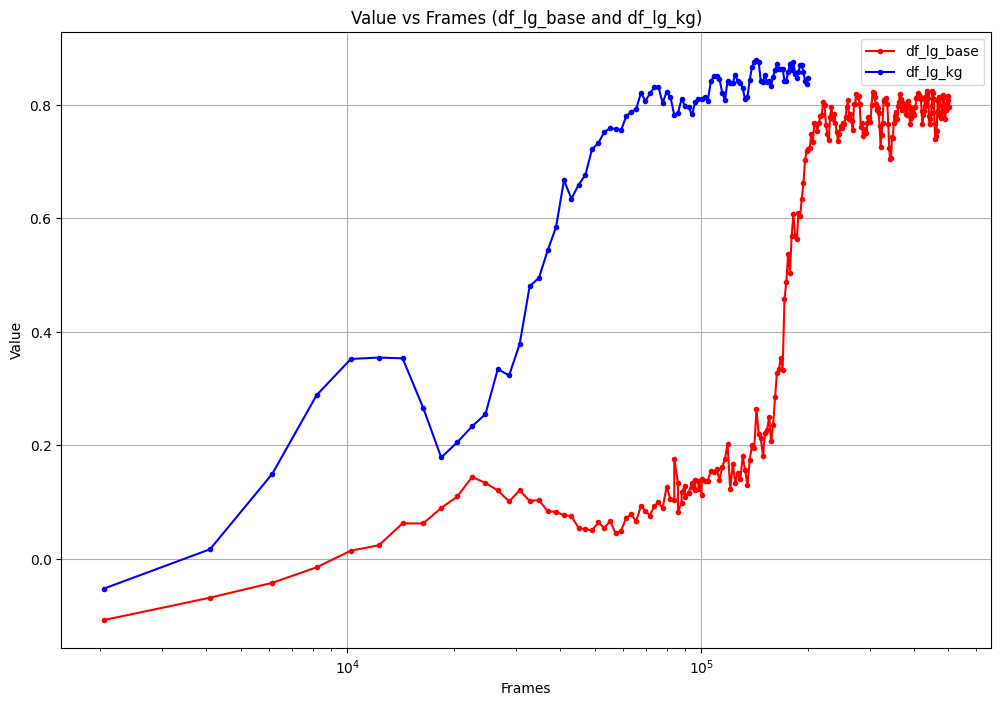

In [39]:
compare_dataframes(df_lg_base, df_lg_kg, 'frames', 'value', ('df_lg_base', 'df_lg_kg'), 'Value vs Frames (df_lg_base and df_lg_kg)')


In [40]:
df_base = read_log(STORAGE_DICT + 'LavaCrossing5/log.csv')
df_base = df_base[df_base['frames'] <= 2500000]

df_kg = read_log(STORAGE_DICT + 'LavaCrossingS9N1_FO_1/log.csv')
df_kg.head()

,update,frames,FPS,duration,rreturn_mean,rreturn_std,rreturn_min,rreturn_max,num_frames_mean,num_frames_std,...,num_frames_max,entropy,value,policy_loss,value_loss,grad_norm,return_mean,return_std,return_min,return_max
0,1,2048,13.364355415419706,153,0.0,0.0,0.0,0.0,26.76,21.93769358888942,...,94.0,1.3625730723142624,-0.08146032691001892,-0.04939724924042821,0.0028178261127322912,0.09982516851211712,0.0,0.0,0.0,0.0
1,2,4096,12.475326338976988,317,0.007305936454093619,0.06199292651529117,0.0,0.5333333611488342,28.013698630136986,35.69140687443267,...,168.0,1.297297403216362,-0.03247498068958521,-0.024774613324552774,0.0017751588893588632,0.047051720758400785,0.007305936454093619,0.06199292651529117,0.0,0.5333333611488342
2,3,6144,11.196989214864463,500,0.021078431430984947,0.12486579263885308,0.0,0.894444465637207,34.94117647058823,44.506404811039864,...,204.0,1.3573970645666122,-0.015251090459059924,-0.020932290703058243,0.004118283584830351,0.03873154144685653,0.021078431430984947,0.12486579263885308,0.0,0.894444465637207
3,4,8192,9.919403828343265,706,0.02105624145931668,0.13282214011263618,0.0,0.925000011920929,24.160493827160494,28.892502675733127,...,122.0,1.4469612836837769,0.00014073372585698962,-0.018880793126299977,0.005826103471918032,0.04276425080219949,0.02105624145931668,0.13282214011263618,0.0,0.925000011920929
4,5,10240,10.713977944595838,897,0.020555555252801803,0.12062910567844305,0.0,0.8166666626930237,20.16190476190476,24.449802340041938,...,137.0,1.6337381601333618,0.024617359973490238,-0.0028325915554887615,0.005855923518538475,0.03569309609693615,0.020555555252801803,0.12062910567844305,0.0,0.8166666626930237


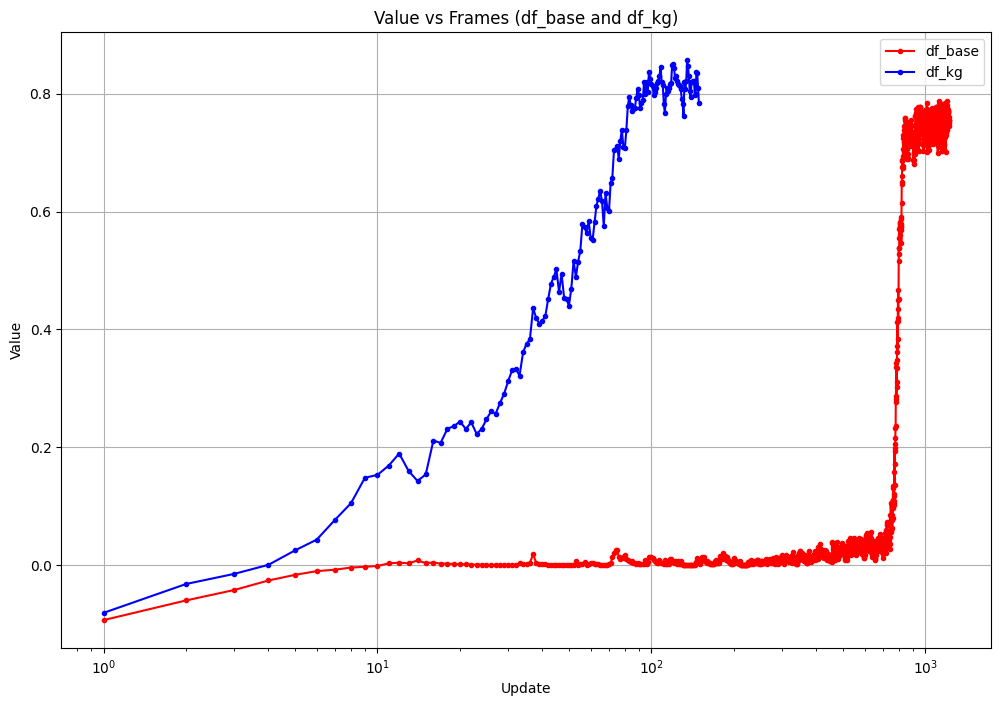

In [41]:
# Example usage
compare_dataframes(df_base, df_kg, 'update', 'value', ('df_base', 'df_kg'), 'Value vs Frames (df_base and df_kg)')

# It is slow

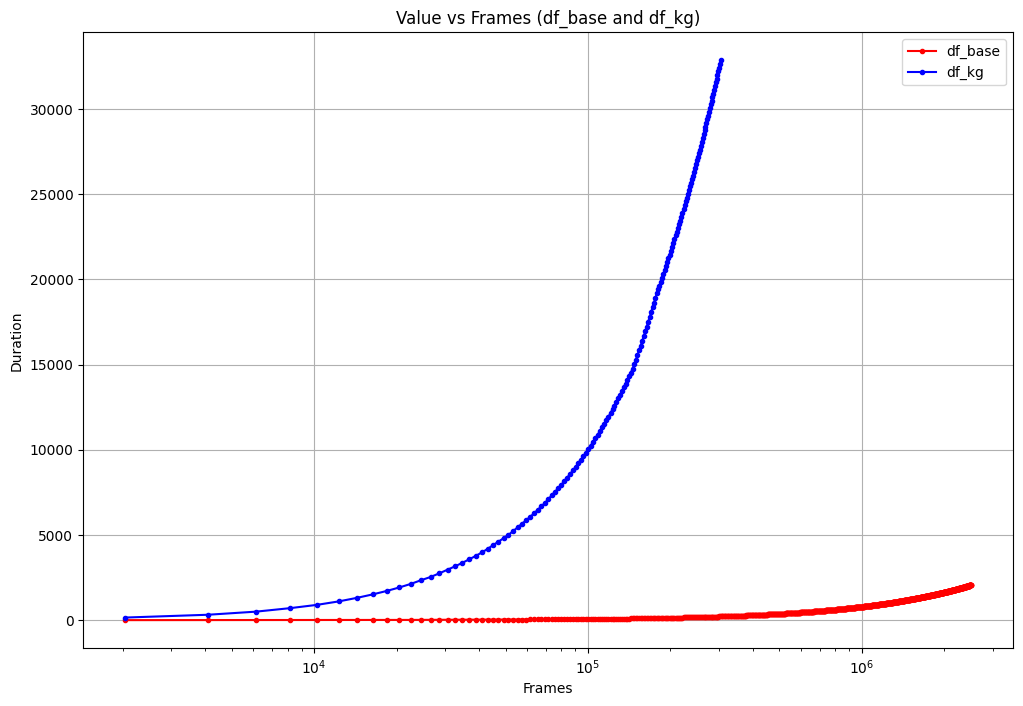

In [42]:
# Example usage
compare_dataframes(df_base, df_kg, 'frames', 'duration', ('df_base', 'df_kg'), 'Value vs Frames (df_base and df_kg)')

In [43]:
# Convert 'duration' column to numeric for both dataframes
df_base['duration'] = pd.to_numeric(df_base['duration'], errors='coerce')
df_kg['duration'] = pd.to_numeric(df_kg['duration'], errors='coerce')

# Calculate average duration per update for each dataframe
avg_duration_base = df_base['duration'].mean()
avg_duration_kg = df_kg['duration'].mean()

# Compare speeds
print(f"Average duration per update (df_base): {avg_duration_base:.2f} seconds")
print(f"Average duration per update (df_kg): {avg_duration_kg:.2f} seconds")

if avg_duration_base < avg_duration_kg:
    ratio = avg_duration_kg / avg_duration_base
    print("df_base is faster. Speed ratio: {:.2f}x".format(ratio))
elif avg_duration_base > avg_duration_kg:
    ratio = avg_duration_base / avg_duration_kg
    print("df_kg is faster. Speed ratio: {:.2f}x".format(ratio))
else:
    print("Both dataframes have the same speed.")

Average duration per update (df_base): 1005.89 seconds
Average duration per update (df_kg): 16230.85 seconds
df_base is faster. Speed ratio: 16.14x


# Batch analysis

In [44]:
BASE_EXP_PATH = "../storage/experiments"

In [45]:
def read_all_experiments(experiment_name):
    """Reads all log files for a given experiment and returns a list of DataFrames."""
    import os
    exp_path = os.path.join(BASE_EXP_PATH, experiment_name)
    dataframes = []
    for root, dirs, files in os.walk(exp_path):
        for file in files:
            if file.endswith('log.csv'):
                file_path = os.path.join(root, file)
                df = read_log(file_path)
                dataframes.append(df)
    return dataframes

In [46]:
def plot_combined_dataframes(dataframes, x_col, y_col, title):
    plt.figure(figsize=(12, 8))
    
    # 1. Prepare and combine data
    all_y_data = []
    
    # Pre-process all dataframes
    for i, df in enumerate(dataframes):
        df = df.copy()  # Avoid modifying the original dataframe
        df[x_col] = pd.to_numeric(df[x_col], errors='coerce')
        df[y_col] = pd.to_numeric(df[y_col], errors='coerce')
        
        # Remove duplicates by grouping: take mean of y values for duplicate x values
        df_grouped = df.groupby(x_col)[y_col].mean()
        df_grouped.name = f'run_{i}'
        all_y_data.append(df_grouped)

    # Combine all series into a single DataFrame based on the shared x_col index
    if all_y_data:
        combined_df = pd.concat(all_y_data, axis=1)

        # 2. Calculate statistics for the band and average
        mean_series = combined_df.mean(axis=1).sort_index()
        min_series = combined_df.min(axis=1).sort_index()
        max_series = combined_df.max(axis=1).sort_index()
        
        # 3. Plot the variability band
        plt.fill_between(
            mean_series.index,
            min_series.values,
            max_series.values,
            color='blue',
            alpha=0.15,
            label='Min/Max Range'
        )
        
        # 4. Plot the distinct average line
        plt.plot(
            mean_series.index, 
            mean_series.values, 
            marker='', 
            linestyle='-',
            linewidth=3,
            alpha=1.0,
            color='darkblue',
            label='Average Run'
        )
        
        # 5. Plot individual runs (without labels)
        for i, df in enumerate(dataframes):
            df = df.copy()
            df[x_col] = pd.to_numeric(df[x_col], errors='coerce')
            df[y_col] = pd.to_numeric(df[y_col], errors='coerce')
            # Group to handle duplicates before plotting
            df_grouped = df.groupby(x_col)[y_col].mean().sort_index()
            plt.plot(
                df_grouped.index, 
                df_grouped.values, 
                marker='', 
                linestyle='-', 
                alpha=0.2,
                color='gray',
            )

    # 6. Finalize the plot
    plt.xlabel(x_col.capitalize())
    plt.ylabel(y_col.capitalize())
    plt.title(title)
    plt.grid(True)
    plt.legend(loc='best') 
    
    plt.show()

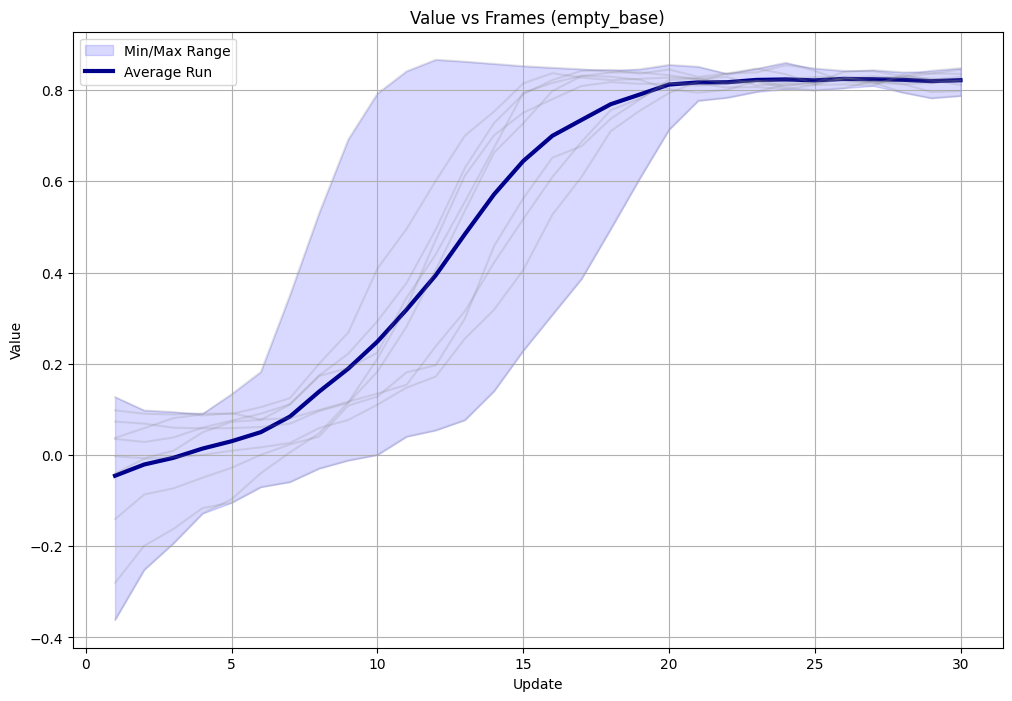

In [47]:
experiment_name = "empty_base"
dataframes = read_all_experiments(experiment_name)

plot_combined_dataframes(dataframes, 'update', 'value', f'Value vs Frames ({experiment_name})')

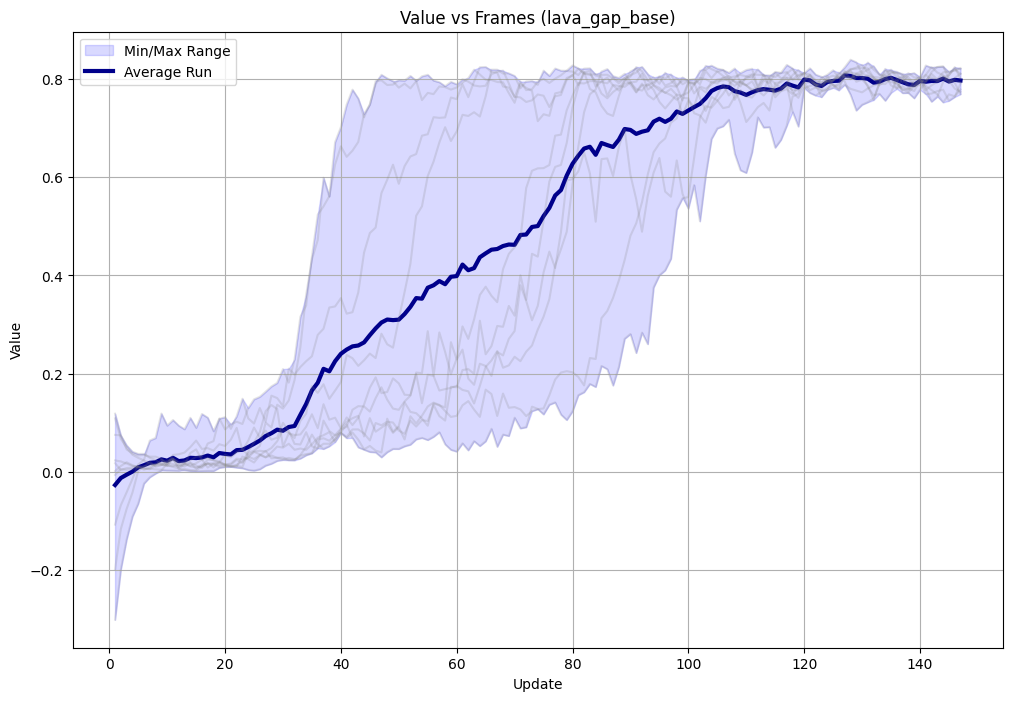

In [48]:
experiment_name = "lava_gap_base"
dataframes = read_all_experiments(experiment_name)

plot_combined_dataframes(dataframes, 'update', 'value', f'Value vs Frames ({experiment_name})')

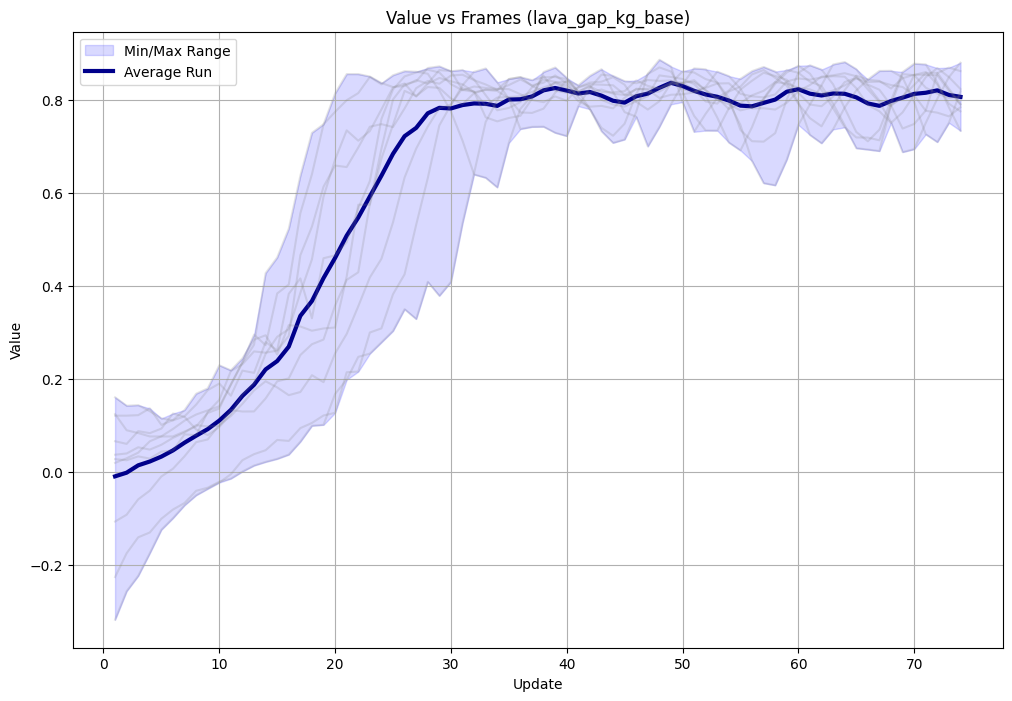

In [49]:
experiment_name = "lava_gap_kg_base"
dataframes = read_all_experiments(experiment_name)

plot_combined_dataframes(dataframes, 'update', 'value', f'Value vs Frames ({experiment_name})')

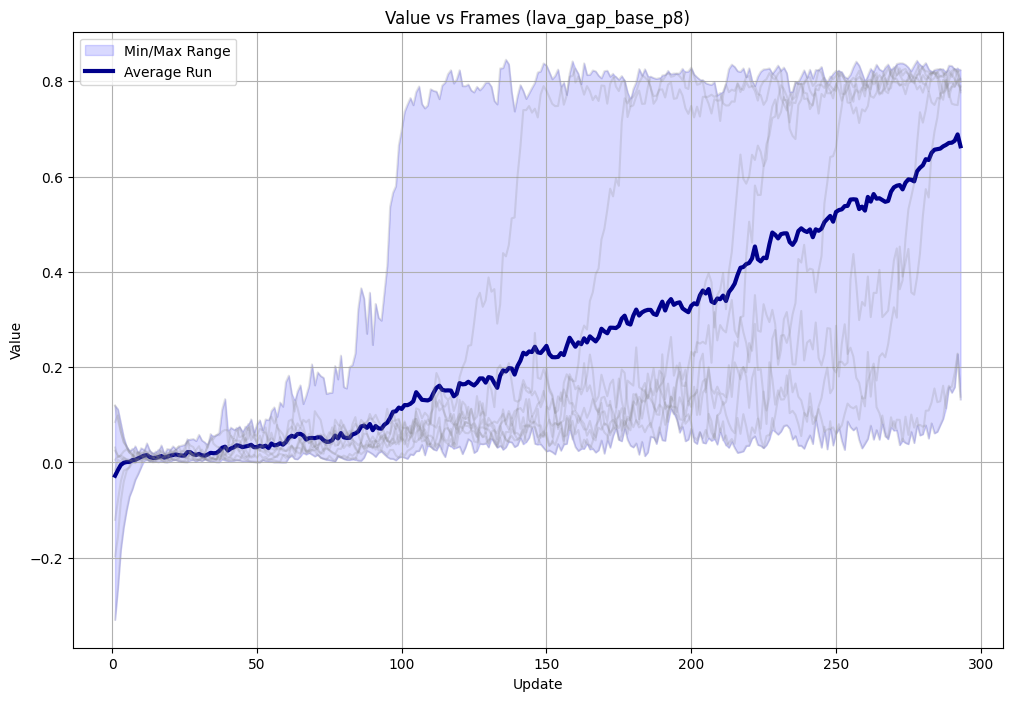

In [50]:
experiment_name = "lava_gap_base_p8"
dataframes = read_all_experiments(experiment_name)

plot_combined_dataframes(dataframes, 'update', 'value', f'Value vs Frames ({experiment_name})')

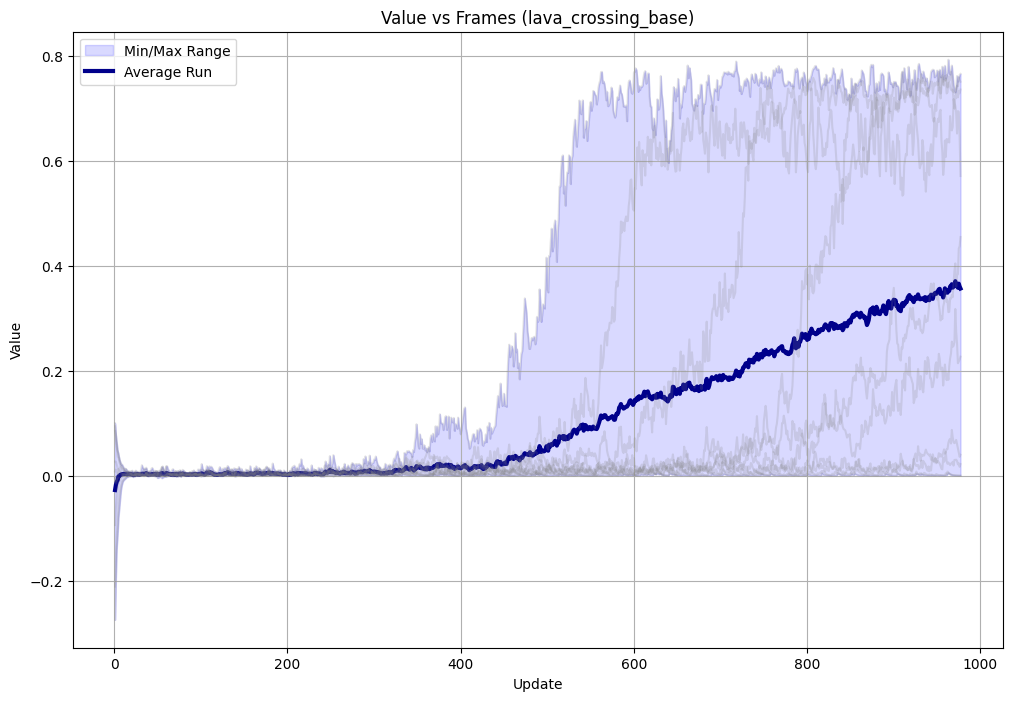

In [51]:
experiment_name = "lava_crossing_base"
dataframes = read_all_experiments(experiment_name)

plot_combined_dataframes(dataframes, 'update', 'value', f'Value vs Frames ({experiment_name})')

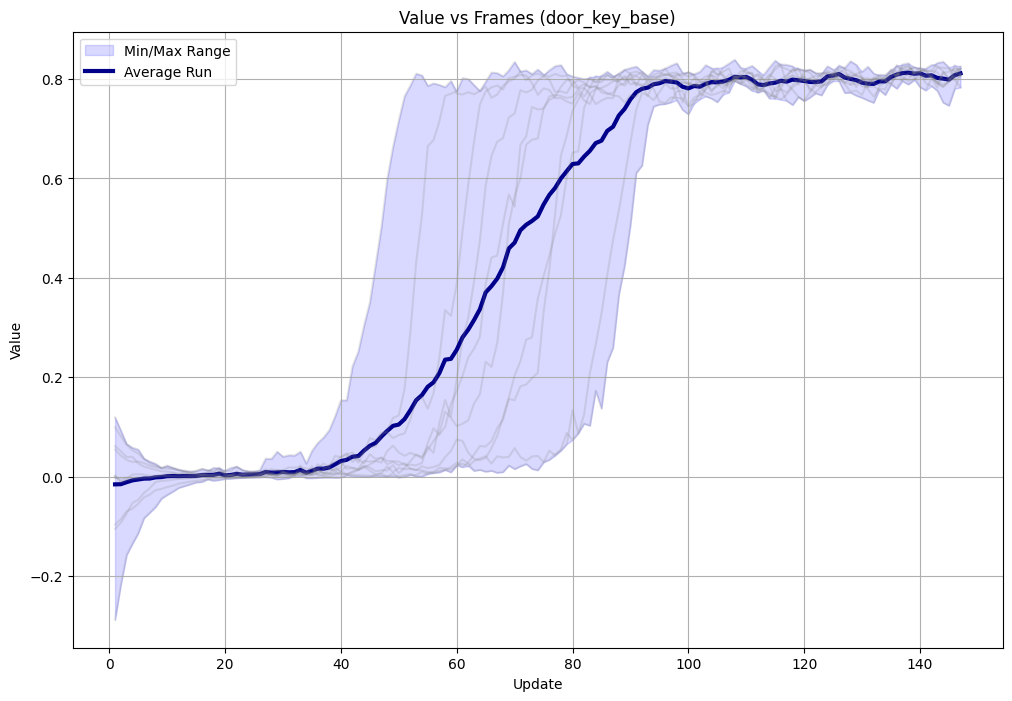

In [52]:
experiment_name = "door_key_base"
dataframes = read_all_experiments(experiment_name)

plot_combined_dataframes(dataframes, 'update', 'value', f'Value vs Frames ({experiment_name})')

# Combined

In [53]:
def plot_dataframes_overlay(dataframes, x_col, y_col, color='blue', label_prefix=''):
    """
    Plot dataframes with min/max band, average line, and individual runs.
    Can be called multiple times to overlay different datasets on the same plot.
    
    Args:
        dataframes: List of dataframes to plot
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        color: Color for the plot elements
        label_prefix: Prefix for legend labels (e.g., 'Dataset A')
    """
    # 1. Prepare and combine data
    all_y_data = []
    
    # Pre-process all dataframes
    for i, df in enumerate(dataframes):
        df = df.copy()  # Avoid modifying the original dataframe
        df[x_col] = pd.to_numeric(df[x_col], errors='coerce')
        df[y_col] = pd.to_numeric(df[y_col], errors='coerce')
        
        # Remove duplicates by grouping: take mean of y values for duplicate x values
        df_grouped = df.groupby(x_col)[y_col].mean()
        df_grouped.name = f'run_{i}'
        all_y_data.append(df_grouped)

    # Combine all series into a single DataFrame based on the shared x_col index
    if all_y_data:
        combined_df = pd.concat(all_y_data, axis=1)

        # 2. Calculate statistics for the band and average
        mean_series = combined_df.mean(axis=1).sort_index()
        min_series = combined_df.min(axis=1).sort_index()
        max_series = combined_df.max(axis=1).sort_index()
        
        # 3. Plot the variability band
        plt.fill_between(
            mean_series.index,
            min_series.values,
            max_series.values,
            color=color,
            alpha=0.1,
            label=f'{label_prefix} Min/Max Range' if label_prefix else 'Min/Max Range'
        )
        
        # 4. Plot the distinct average line
        plt.plot(
            mean_series.index, 
            mean_series.values, 
            marker='', 
            linestyle='-',
            linewidth=3,
            alpha=1.0,
            color=color,
            label=f'{label_prefix} Average' if label_prefix else 'Average Run'
        )
        
        # 5. Plot individual runs (without labels)
        for i, df in enumerate(dataframes):
            df = df.copy()
            df[x_col] = pd.to_numeric(df[x_col], errors='coerce')
            df[y_col] = pd.to_numeric(df[y_col], errors='coerce')
            # Group to handle duplicates before plotting
            df_grouped = df.groupby(x_col)[y_col].mean().sort_index()
            plt.plot(
                df_grouped.index, 
                df_grouped.values, 
                marker='', 
                linestyle='-', 
                alpha=0.2,
                color=color,
            )


def create_combined_plot(x_col, y_col, title, figsize=(12, 8)):
    """
    Create a new figure for plotting. Call this before using plot_dataframes_overlay.
    
    Args:
        x_col: Column name for x-axis
        y_col: Column name for y-axis
        title: Plot title
        figsize: Figure size tuple
    """
    plt.figure(figsize=figsize)
    plt.xlabel(x_col.capitalize())
    plt.ylabel(y_col.capitalize())
    plt.title(title)
    plt.grid(True)


def finalize_plot():
    """
    Finalize and display the plot. Call this after all plot_dataframes_overlay calls.
    """
    plt.legend(loc='best')
    plt.show()

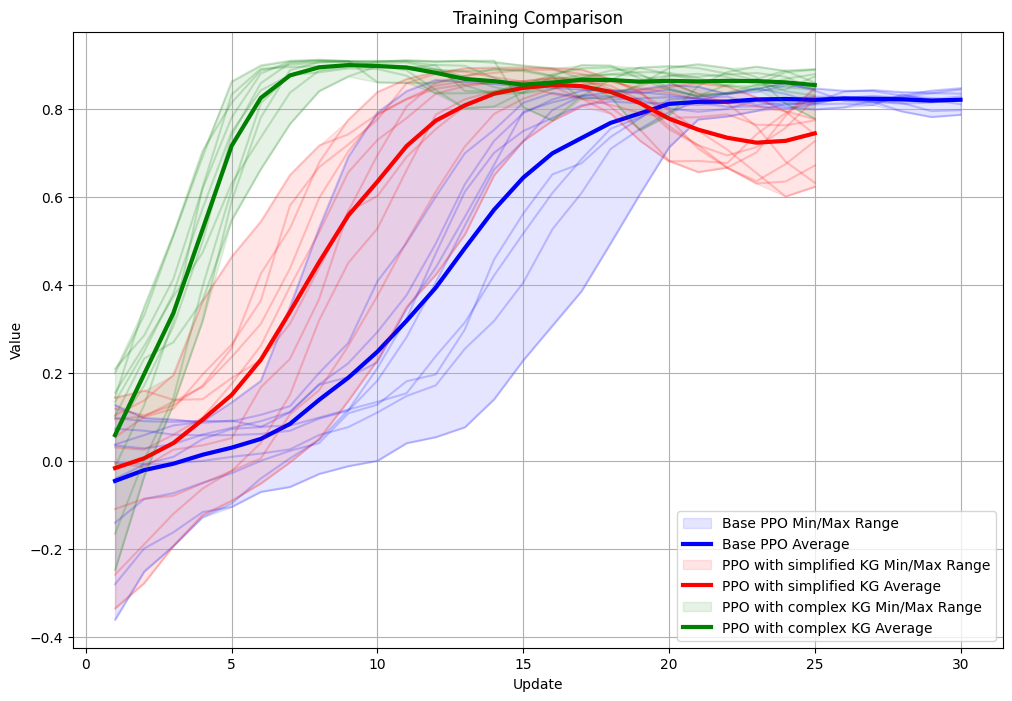

In [54]:
experiment_name_base = "empty_base"
dataframes_base = read_all_experiments(experiment_name_base)

experiment_name_kg = "empty_kg_base"
dataframes_kg = read_all_experiments(experiment_name_kg)

experiment_name_kg_com = "empty_kg_complex"
dataframes_kg_com = read_all_experiments(experiment_name_kg_com)

# Plot two different datasets on the same figure
create_combined_plot('update', 'value', 'Training Comparison')

# First dataset in blue
plot_dataframes_overlay(dataframes_base, 'update', 'value', color='blue', label_prefix='Base PPO')

# Second dataset in red
plot_dataframes_overlay(dataframes_kg, 'update', 'value', color='red', label_prefix='PPO with simplified KG')

# Third dataset in green
plot_dataframes_overlay(dataframes_kg_com, 'update', 'value', color='green', label_prefix='PPO with complex KG')

finalize_plot()

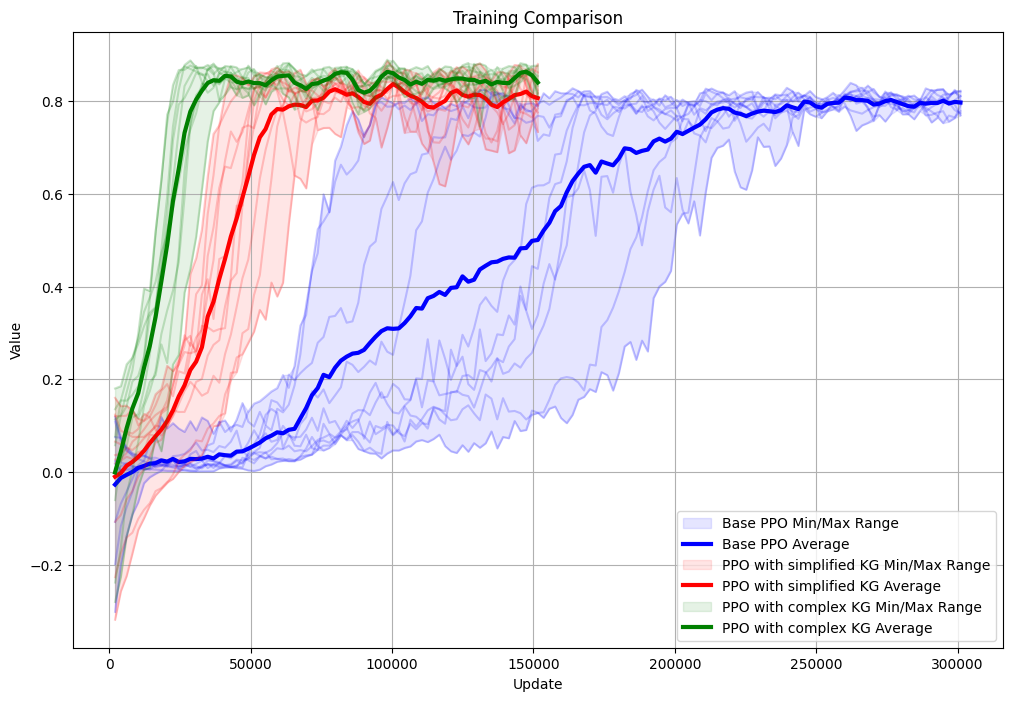

In [ ]:
experiment_name_base = "lava_gap_base"
dataframes_base = read_all_experiments(experiment_name_base)

experiment_name_kg = "lava_gap_kg_base"
dataframes_kg = read_all_experiments(experiment_name_kg)

experiment_name_kg_com = "lava_gap_kg_complex"
dataframes_kg_com = read_all_experiments(experiment_name_kg_com)

# Plot two different datasets on the same figure
create_combined_plot('update', 'value', 'Training Comparison')

# First dataset in blue
plot_dataframes_overlay(dataframes_base, 'update', 'value', color='blue', label_prefix='Base PPO')

# Second dataset in red
plot_dataframes_overlay(dataframes_kg, 'update', 'value', color='red', label_prefix='PPO with simplified KG')

# Third dataset in green
plot_dataframes_overlay(dataframes_kg_com, 'update', 'value', color='green', label_prefix='PPO with complex KG')

finalize_plot()

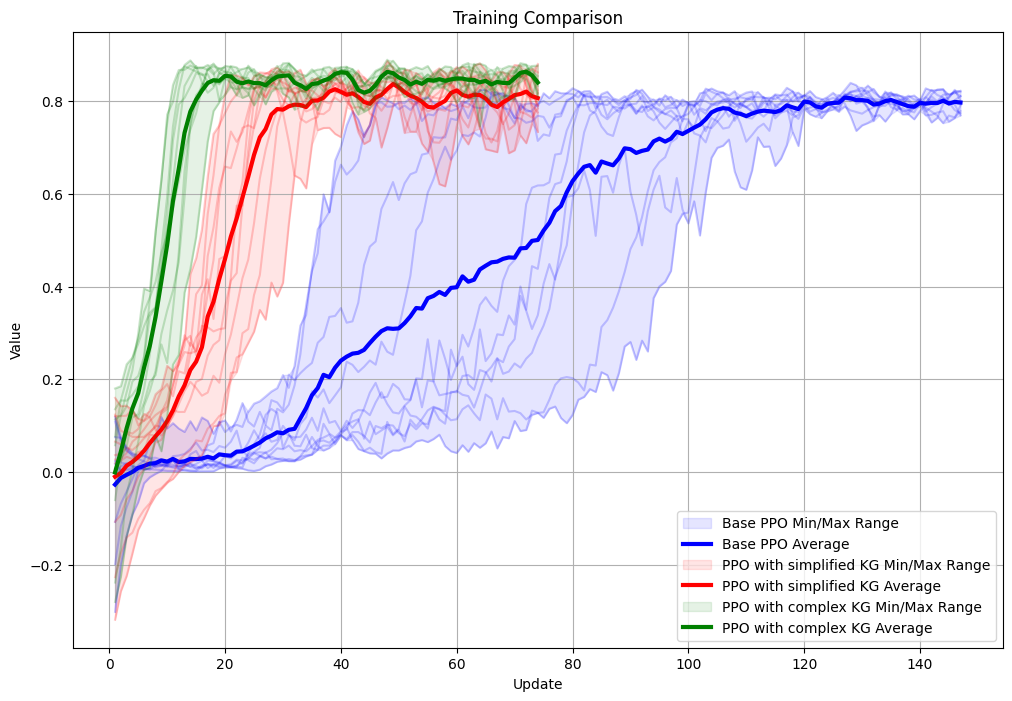

In [61]:
experiment_name_base = "lava_gap_base"
dataframes_base = read_all_experiments(experiment_name_base)

experiment_name_kg = "lava_gap_kg_base"
dataframes_kg = read_all_experiments(experiment_name_kg)

experiment_name_kg_com = "lava_gap_kg_complex"
dataframes_kg_com = read_all_experiments(experiment_name_kg_com)

# Plot two different datasets on the same figure
create_combined_plot('update', 'value', 'Training Comparison')

# First dataset in blue
plot_dataframes_overlay(dataframes_base, 'update', 'value', color='blue', label_prefix='Base PPO')

# Second dataset in red
plot_dataframes_overlay(dataframes_kg, 'update', 'value', color='red', label_prefix='PPO with simplified KG')

# Third dataset in green
plot_dataframes_overlay(dataframes_kg_com, 'update', 'value', color='green', label_prefix='PPO with complex KG')

finalize_plot()

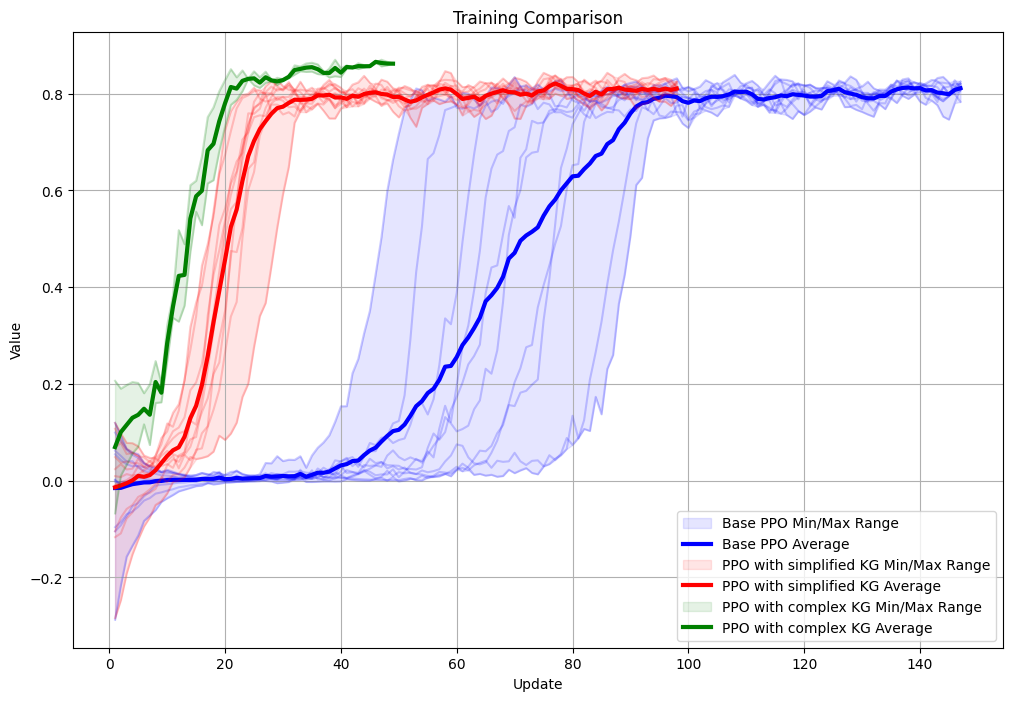

In [ ]:
experiment_name_base = "door_key_base"
dataframes_base = read_all_experiments(experiment_name_base)

experiment_name_kg = "door_key_kg_base"
dataframes_kg = read_all_experiments(experiment_name_kg)

experiment_name_kg_com = "door_key_kg_complex"
dataframes_kg_com = read_all_experiments(experiment_name_kg_com)

# Plot two different datasets on the same figure
create_combined_plot('update', 'value', 'Training Comparison')

# First dataset in blue
plot_dataframes_overlay(dataframes_base, 'update', 'value', color='blue', label_prefix='Base PPO')

# Second dataset in red
plot_dataframes_overlay(dataframes_kg, 'update', 'value', color='red', label_prefix='PPO with simplified KG')

# Third dataset in green
plot_dataframes_overlay(dataframes_kg_com, 'update', 'value', color='green', label_prefix='PPO with complex KG')

finalize_plot()

# Other

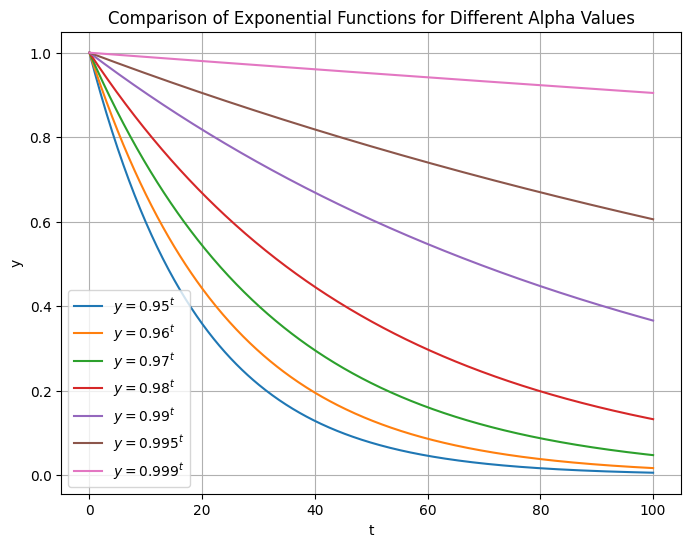

In [62]:
import numpy as np

import matplotlib.pyplot as plt

# Define the function
t = np.linspace(0, 100, 500)

alpha = [0.95, 0.96, 0.97, 0.98, 0.99, 0.995, 0.999]

y = {a: a**t for a in alpha}

# Plot the function
plt.figure(figsize=(8, 6))
for a in alpha:
    plt.plot(t, y[a], label=f'$y={a}^t$')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Comparison of Exponential Functions for Different Alpha Values')
plt.grid(True)
plt.legend()
plt.show()